# Linear Discriminant Analysis: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind Linear Discriminant Analysis (full derivation)
2. Worked examples using actual HMEQ data
3. Model training with hyperparameter tuning
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports for this notebook
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import scipy.stats as stats

MODEL_NAME = "Linear Discriminant Analysis"
MODEL_SLUG = "lda"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind Linear Discriminant Analysis

### 2.1 The Problem

We want to classify borrowers into two groups (default vs. good) by finding a linear combination of features that best separates the two classes. LDA approaches this by assuming each class follows a Gaussian (normal) distribution with the same covariance matrix, then finds the direction of maximum class separation.

### 2.2 Fisher's Criterion

The key insight is **Fisher's criterion**: find the projection direction **w** that maximizes the ratio of between-class scatter to within-class scatter.

**Between-class scatter matrix:**

$$S_B = (\boldsymbol{\mu}_1 - \boldsymbol{\mu}_0)(\boldsymbol{\mu}_1 - \boldsymbol{\mu}_0)^T$$

where $\boldsymbol{\mu}_0$ and $\boldsymbol{\mu}_1$ are the mean vectors for the two classes.

**Within-class scatter matrix:**

$$S_W = \sum_{i=0}^{1} \sum_{x \in \text{class } i} (x - \boldsymbol{\mu}_i)(x - \boldsymbol{\mu}_i)^T$$

This is the pooled covariance matrix, weighted by class proportions.

**Fisher's criterion (ratio to maximize):**

$$J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$$

This is a **generalized eigenvalue problem**. The optimal direction **w** is the eigenvector of $S_W^{-1} S_B$ with the largest eigenvalue.

### 2.3 The LDA Discriminant Function

Once we have the optimal direction **w**, we project each sample onto it to get a **discriminant score**:

$$\delta(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$$

where **b** is a bias term that positions the decision boundary based on the prior probabilities of each class.

### 2.4 Class Conditional Distributions

LDA assumes:
- Class 0 (good loans): $\mathbf{x} \mid Y=0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \Sigma)$
- Class 1 (defaults): $\mathbf{x} \mid Y=1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \Sigma)$

Same covariance matrix $\Sigma$ for both classes. This is a strong assumption but makes the math tractable.

Given these distributions, the posterior probability of default is:

$$P(Y=1 \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid Y=1) \pi_1}{p(\mathbf{x} \mid Y=1) \pi_1 + p(\mathbf{x} \mid Y=0) \pi_0}$$

where $\pi_0, \pi_1$ are the prior class probabilities.

### 2.5 Decision Boundary

The decision boundary (where $P(Y=1 \mid \mathbf{x}) = P(Y=0 \mid \mathbf{x})$) is a **linear hyperplane** in feature space:

$$\mathbf{w}^T (\mathbf{x} - \mathbf{x}_0) = 0$$

This defines the direction perpendicular to the boundary. Points on the "good" side have lower discriminant scores; points on the "default" side have higher scores.

### 2.6 Training Objective

LDA has no iterative optimization step (unlike logistic regression). It is solved in closed form:

1. **Compute class means:** $\boldsymbol{\mu}_0, \boldsymbol{\mu}_1$
2. **Compute pooled covariance:** $\Sigma$
3. **Solve generalized eigenvalue problem:** $S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$
4. **Extract eigenvector with largest eigenvalue** to get the discriminant direction
5. **Set decision boundary** based on class priors

---
## 3. Visualizing the Discriminant Function

LDA Coefficient vector (direction of maximum separation):
  Shape: (1, 25)
  Intercept: [-2.68756627]

Top 10 coefficients by absolute value:
        feature  coefficient
DEBTINC_missing     1.839310
      JOB_Sales     1.445306
         DELINQ     1.014822
       JOB_Self     0.731565
        JOB_nan    -0.573722
     JOB_Office    -0.557861
          DEROG     0.539294
        DEBTINC     0.471030
          CLAGE    -0.420141
  DEROG_missing    -0.348140


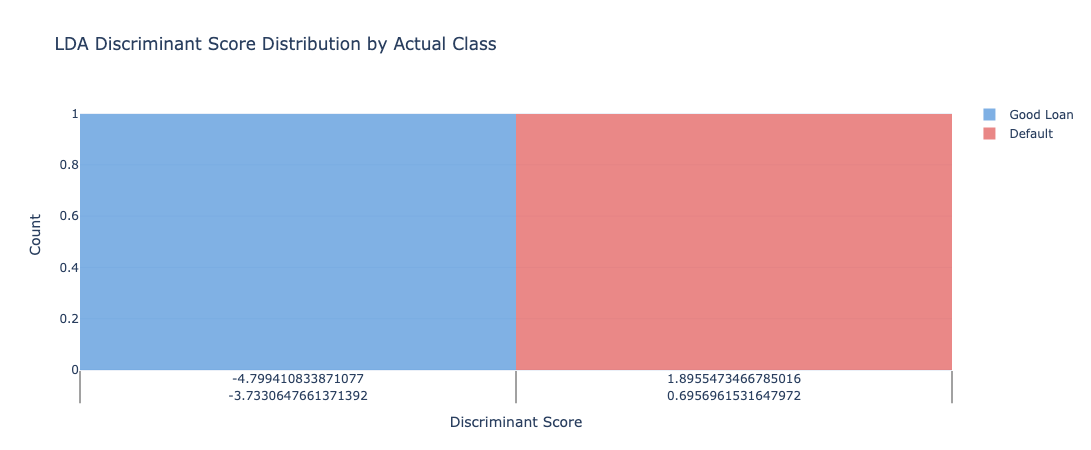

In [2]:
# Train LDA on the full preprocessed data
lda_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", LinearDiscriminantAnalysis(solver="svd")),
])
lda_pipe.fit(X_train, y_train)

# Extract the fitted model
lda_model = lda_pipe.named_steps["clf"]
preprocessor = lda_pipe.named_steps["prep"]

# Get feature names
num_names = numeric_features
cat_encoder = preprocessor.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = num_names + cat_names

print("LDA Coefficient vector (direction of maximum separation):")
print(f"  Shape: {lda_model.coef_.shape}")
print(f"  Intercept: {lda_model.intercept_}")
print()
print("Top 10 coefficients by absolute value:")
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": lda_model.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)
print(coef_df.head(10).to_string(index=False))

# Compute discriminant scores on the full training set
X_train_transformed = preprocessor.transform(X_train)
discriminant_scores_train = X_train_transformed @ lda_model.coef_.T + lda_model.intercept_

# Plot discriminant score distribution by class
fig = go.Figure()

for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_train == label
    fig.add_trace(go.Histogram(
        x=discriminant_scores_train[mask],
        name=name,
        opacity=0.7,
        nbinsx=40,
        marker_color=color,
    ))

fig.update_layout(
    title="LDA Discriminant Score Distribution by Actual Class",
    xaxis_title="Discriminant Score",
    yaxis_title="Count",
    barmode="overlay",
    height=450, width=700,
)
fig.show()

---
## 4. Worked Example with HMEQ Data

Let's manually compute the discriminant score for real borrowers from the dataset.

In [3]:
# Pick 3 example borrowers
examples = get_example_rows(df, n=3)

print("=" * 80)
print("WORKED EXAMPLE: Manual LDA Discriminant Score Calculation")
print("=" * 80)

for idx, row in examples.iterrows():
    print_example_row(row, idx)

    # Transform through preprocessor
    row_df = pd.DataFrame([row.drop(TARGET)])
    # Fill in missing flag columns
    for c in [col for col in df_proc.columns if col.endswith("_missing")]:
        base_col = c.replace("_missing", "")
        if base_col in row_df.columns:
            row_df[c] = row_df[base_col].isna().astype(int)
        else:
            row_df[c] = 0

    X_transformed = preprocessor.transform(row_df[X_train.columns])

    # Compute discriminant score: w^T x + b
    disc_score = np.dot(X_transformed[0], lda_model.coef_[0]) + lda_model.intercept_

    # Get probability prediction from the model
    prob = lda_pipe.predict_proba(row_df[X_train.columns])[0, 1]

    print()
    print("  Step 1: Compute discriminant score = w^T x + b")
    print(f"          w^T x = {np.dot(X_transformed[0], lda_model.coef_[0]):.4f}")
    print(f"          + intercept = {lda_model.intercept_[0]:.4f}")
    print(f"          = {float(disc_score):.4f}")
    print()
    print("  Step 2: Convert to probability via Gaussian assumption")
    print(f"          P(default | x) ≈ {prob:.4f}")
    print()
    print("  Step 3: Classify (threshold = 0.5)")
    prediction = "DEFAULT" if prob >= 0.5 else "GOOD"
    actual = "DEFAULT" if row[TARGET] == 1 else "GOOD"
    match = "✓ CORRECT" if prediction == actual else "✗ INCORRECT"
    print(f"          {prob:.4f} {'≥' if prob >= 0.5 else '<'} 0.5 → Predict: {prediction}")
    print(f"          Actual: {actual}  {match}")
    print()

WORKED EXAMPLE: Manual LDA Discriminant Score Calculation

--- Example Borrower 1 (Actual: GOOD) ---
  LOAN           : 10600
  MORTDUE        : 82365.0
  VALUE          : 100272.0
  REASON         : DebtCon
  JOB            : ProfExe
  YOJ            : 3.0
  DEROG          : 1.0
  DELINQ         : 0.0
  CLAGE          : 122.48359427
  NINQ           : 0.0
  CLNO           : 26.0
  DEBTINC        : 33.651646949

  Step 1: Compute discriminant score = w^T x + b
          w^T x = -0.8267
          + intercept = -2.6876
          = -3.5143

  Step 2: Convert to probability via Gaussian assumption
          P(default | x) ≈ 0.0289

  Step 3: Classify (threshold = 0.5)
          0.0289 < 0.5 → Predict: GOOD
          Actual: GOOD  ✓ CORRECT


--- Example Borrower 2 (Actual: GOOD) ---
  LOAN           : 24800
  MORTDUE        : 82670.0
  VALUE          : 106563.0
  REASON         : DebtCon
  JOB            : Mgr
  YOJ            : 8.0
  DEROG          : 0.0
  DELINQ         : 0.0
  CLAGE    

---
## 5. Class Means and Pooled Covariance

Understanding the distributions that LDA learned.

Class Means (in transformed feature space):
  Good loans (Class 0): [ 0.04331767  0.03437491  0.02734037  0.02335624 -0.13552225]... (showing first 5 features)
  Defaults (Class 1):   [-0.17375629 -0.13788499 -0.109668   -0.09368681  0.54360829]...
  Difference (mu_1 - mu_0): [-0.21707396 -0.1722599  -0.13700837 -0.11704305  0.67913054]...

Pooled Covariance Matrix Shape: (25, 25)
  Condition number: 1.19e+17
  (Small condition number = well-conditioned, numerically stable)


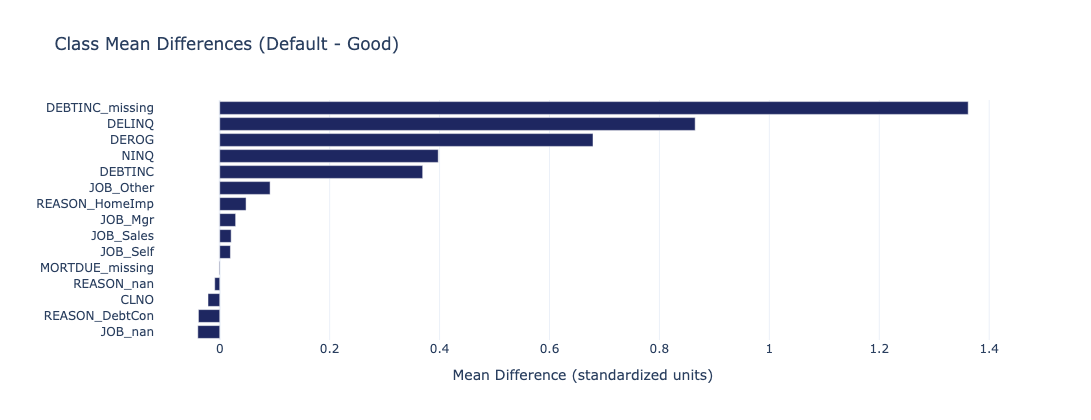

  Saved: outputs/lda/class_mean_differences.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lda/class_mean_differences.html')

In [4]:
# Extract class means (from the LDA model)
mu_0 = lda_model.means_[0]
mu_1 = lda_model.means_[1]

print("Class Means (in transformed feature space):")
print(f"  Good loans (Class 0): {mu_0[:5]}... (showing first 5 features)")
print(f"  Defaults (Class 1):   {mu_1[:5]}...")
print(f"  Difference (mu_1 - mu_0): {(mu_1 - mu_0)[:5]}...")

# Compute pooled covariance matrix manually from training data
X_train_centered_0 = X_train_transformed[y_train == 0] - mu_0
X_train_centered_1 = X_train_transformed[y_train == 1] - mu_1

n_0 = len(X_train_centered_0)
n_1 = len(X_train_centered_1)
n_total = n_0 + n_1

cov_0 = (X_train_centered_0.T @ X_train_centered_0) / n_0
cov_1 = (X_train_centered_1.T @ X_train_centered_1) / n_1

# Pooled covariance (LDA assumption: same covariance for both classes)
covariance = (n_0 * cov_0 + n_1 * cov_1) / n_total

print()
print(f"Pooled Covariance Matrix Shape: {covariance.shape}")
print(f"  Condition number: {np.linalg.cond(covariance):.2e}")
print(f"  (Small condition number = well-conditioned, numerically stable)")

# Visualize the difference between means
diff = mu_1 - mu_0
diff_df = pd.DataFrame({
    "feature": all_feature_names,
    "mean_diff": diff,
}).sort_values("mean_diff", ascending=True)

fig_diff = px.bar(
    diff_df.tail(15), x="mean_diff", y="feature", orientation="h",
    title="Class Mean Differences (Default - Good)",
    color_discrete_sequence=[COLORS["navy"]],
    height=max(350, len(diff_df.tail(15)) * 28),
)
fig_diff.update_layout(yaxis_title="", xaxis_title="Mean Difference (standardized units)")
fig_diff.show()
save_chart(fig_diff, MODEL_SLUG, "class_mean_differences")

---
## 6. Hyperparameter Tuning

LDA has fewer hyperparameters than logistic regression, but the solver and shrinkage options matter.

In [5]:
# Test different solvers and shrinkage strategies
configs = [
    {"solver": "svd", "shrinkage": None, "name": "SVD (no shrinkage)"},
    {"solver": "lsqr", "shrinkage": None, "name": "LSQR (no shrinkage)"},
    {"solver": "eigen", "shrinkage": None, "name": "Eigen (no shrinkage)"},
    {"solver": "lsqr", "shrinkage": "auto", "name": "LSQR (auto shrinkage)"},
    {"solver": "lsqr", "shrinkage": 0.3, "name": "LSQR (shrinkage=0.3)"},
    {"solver": "lsqr", "shrinkage": 0.5, "name": "LSQR (shrinkage=0.5)"},
]

results = []
print("=" * 70)
print("Hyperparameter Tuning: Cross-validated Performance")
print("=" * 70)

for config in configs:
    lda_temp = Pipeline([
        ("prep", prep_linear),
        ("clf", LinearDiscriminantAnalysis(**{k: v for k, v in config.items() if k != "name"})),
    ])

    cv_scores = cross_val_score(lda_temp, X_train, y_train, cv=cv, scoring="roc_auc")
    mean_score = cv_scores.mean()

    results.append({
        "config": config["name"],
        "mean_auc": mean_score,
        "std_auc": cv_scores.std(),
    })

    print(f"{config['name']:30s}  AUC: {mean_score:.4f} (+/- {cv_scores.std():.4f})")

# Use the best configuration
best_config = max(results, key=lambda x: x["mean_auc"])
print()
print(f"Best configuration: {best_config['config']}")

Hyperparameter Tuning: Cross-validated Performance
SVD (no shrinkage)              AUC: 0.8921 (+/- 0.0145)
LSQR (no shrinkage)             AUC: 0.8922 (+/- 0.0146)
Eigen (no shrinkage)            AUC: nan (+/- nan)
LSQR (auto shrinkage)           AUC: 0.8922 (+/- 0.0146)
LSQR (shrinkage=0.3)            AUC: 0.8900 (+/- 0.0157)
LSQR (shrinkage=0.5)            AUC: 0.8884 (+/- 0.0159)

Best configuration: LSQR (no shrinkage)


---
## 7. Model Training and Evaluation

We use the standard LDA configuration: `solver='auto'`, `shrinkage=None`.

In [6]:
# Train final model
lda_pipe_final = Pipeline([
    ("prep", prep_linear),
    ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])
lda_pipe_final.fit(X_train, y_train)

# Evaluate on test set
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, lda_pipe_final, X_test, y_test)

print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))


  Linear Discriminant Analysis
  Recall: 0.6532  |  Precision: 0.7004  |  F1: 0.6760
  AUC: 0.8829  |  PR-AUC: 0.7481
  Confusion: TP=194 FP=83 FN=103 TN=1110

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.92      0.93      0.92      1193
     Default       0.70      0.65      0.68       297

    accuracy                           0.88      1490
   macro avg       0.81      0.79      0.80      1490
weighted avg       0.87      0.88      0.87      1490



---
## 8. Diagnostic Charts


Saving universal charts for Linear Discriminant Analysis:
  Saved: outputs/lda/roc_curve.html
  Saved: outputs/lda/precision_recall_curve.html
  Saved: outputs/lda/confusion_matrix.html
  Saved: outputs/lda/threshold_sweep.html


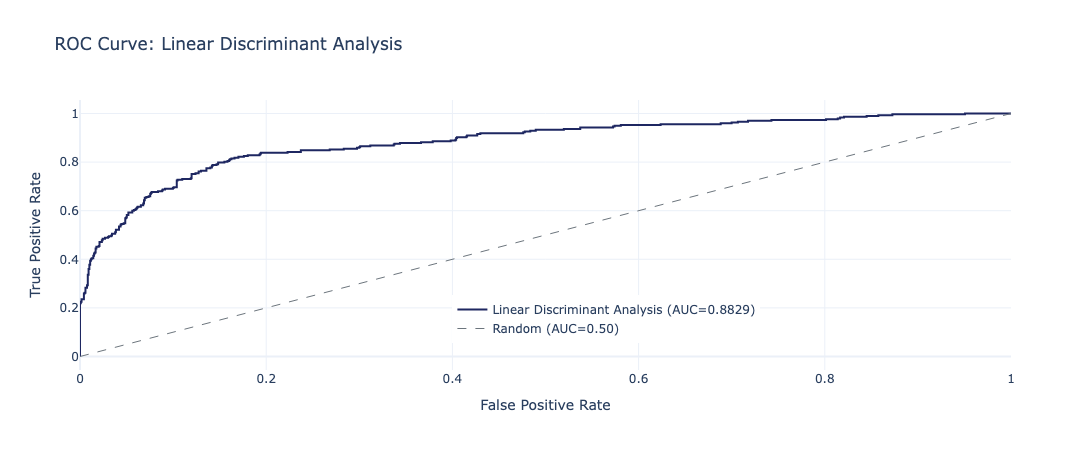

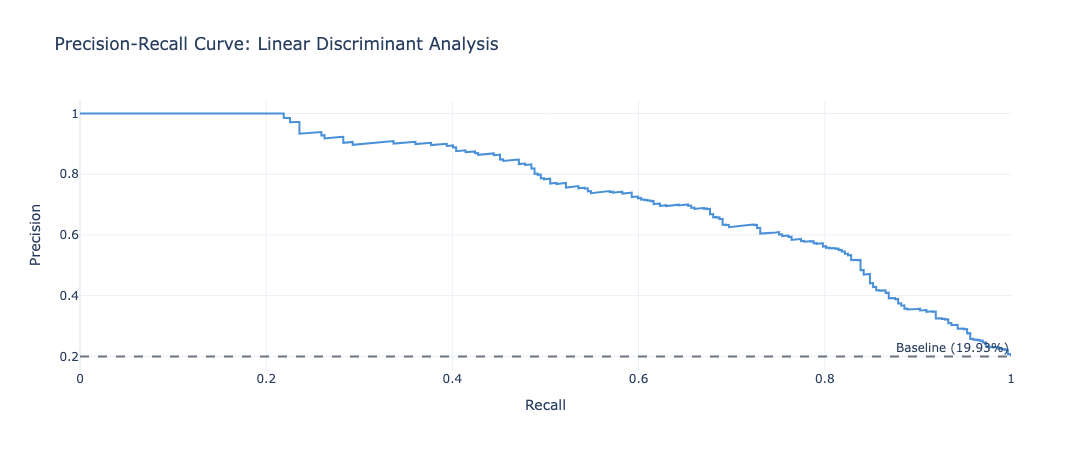

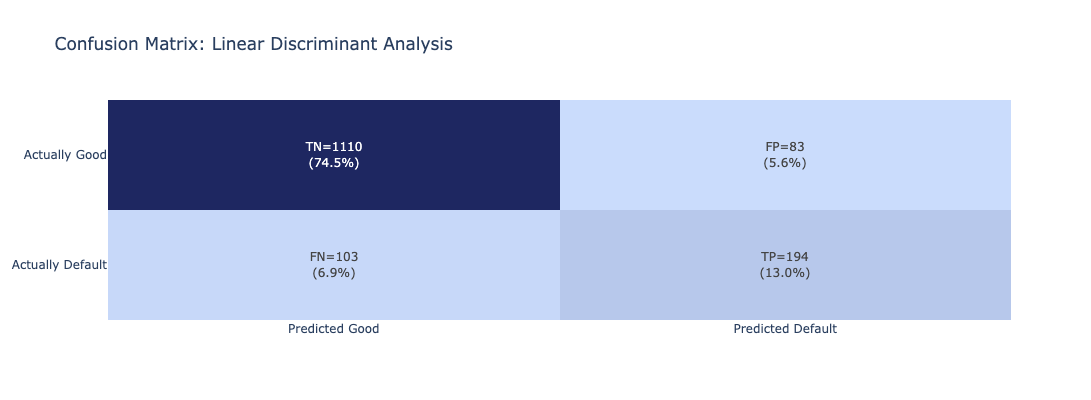

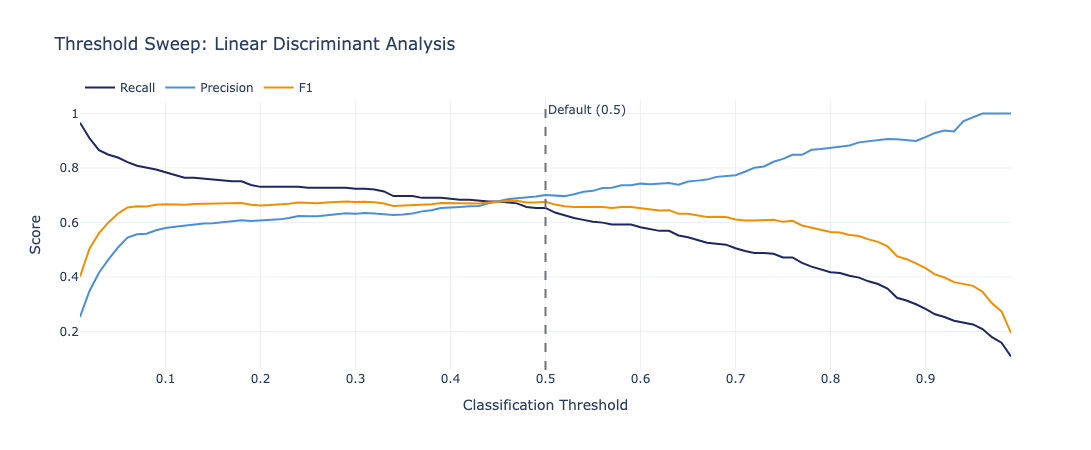

In [7]:
# Generate and save all universal charts
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)

# Show them inline too
for name, fig in charts.items():
    fig.show()

---
## 9. Predicted Probability Distribution

How are the model's predicted probabilities distributed across the two classes?

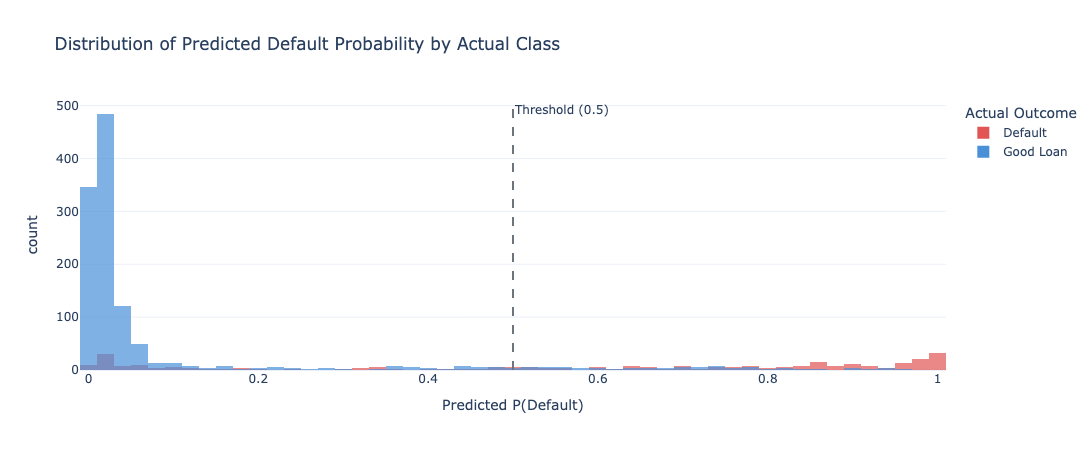

  Saved: outputs/lda/probability_distribution.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lda/probability_distribution.html')

In [8]:
# Probability distribution by actual class
prob_df = pd.DataFrame({
    "probability": y_score,
    "actual": y_test.map({0: "Good Loan", 1: "Default"}).values,
})

fig_prob = px.histogram(
    prob_df, x="probability", color="actual",
    nbins=50, barmode="overlay", opacity=0.7,
    title="Distribution of Predicted Default Probability by Actual Class",
    labels={"probability": "Predicted P(Default)", "actual": "Actual Outcome"},
    color_discrete_map={"Good Loan": COLORS["accent"], "Default": COLORS["red"]},
    height=450, width=650,
)
fig_prob.add_vline(x=0.5, line_dash="dash", line_color=COLORS["gray"],
                   annotation_text="Threshold (0.5)")
fig_prob.show()
save_chart(fig_prob, MODEL_SLUG, "probability_distribution")

In [ ]:
# Discriminant Score Distribution by Class
X_test_prep = lda_pipe_final.named_steps['prep'].transform(X_test)
lda_clf = lda_pipe_final.named_steps['clf']
scores = X_test_prep @ lda_clf.coef_.T + lda_clf.intercept_

fig_disc = go.Figure()
for label, color, name in [(0, COLORS['accent'], 'Good Loan'), (1, COLORS['red'], 'Default')]:
    mask = y_test == label
    fig_disc.add_trace(go.Histogram(
        x=scores[mask], name=name, opacity=0.7,
        marker_color=color, nbinsx=40,
    ))
fig_disc.update_layout(
    title='LDA Discriminant Score Distribution by Class',
    xaxis_title='Discriminant Score (projection onto optimal direction)',
    yaxis_title='Count',
    barmode='overlay',
    height=450, width=700,
    legend=dict(x=0.75, y=0.95),
)
fig_disc.show()
save_chart(fig_disc, MODEL_SLUG, 'discriminant_distribution')

---
## 10. Class Separation in Discriminant Space

Visualize how well the two classes separate along the primary discriminant axis.

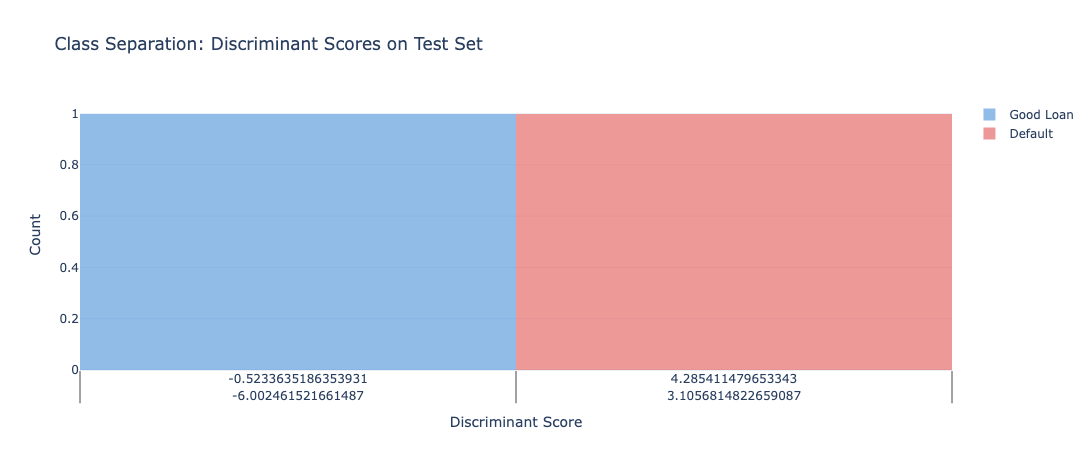

  Saved: outputs/lda/class_separation.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/lda/class_separation.html')

In [9]:
# Project both train and test sets onto the first discriminant axis
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

disc_train = X_train_transformed @ lda_model.coef_.T + lda_model.intercept_
disc_test = X_test_transformed @ lda_model.coef_.T + lda_model.intercept_

# Create overlapping histograms of discriminant scores
fig_sep = go.Figure()

for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask_test = y_test == label
    fig_sep.add_trace(go.Histogram(
        x=disc_test[mask_test],
        name=name,
        opacity=0.6,
        nbinsx=30,
        marker_color=color,
    ))

fig_sep.update_layout(
    title="Class Separation: Discriminant Scores on Test Set",
    xaxis_title="Discriminant Score",
    yaxis_title="Count",
    barmode="overlay",
    height=450, width=700,
)
fig_sep.show()
save_chart(fig_sep, MODEL_SLUG, "class_separation")

---
## 11. Summary

### Where Linear Discriminant Analysis Sits on the Tradeoff Spectrum

LDA with a shared covariance assumption tends toward the **moderate** end of the spectrum. It makes a strong parametric assumption (Gaussian distributions), which constrains the decision boundary to be linear. This sometimes gives stable, interpretable results; other times it sacrifices accuracy for simplicity.

### Strengths for This Problem
- Closed-form solution (no iterative optimization needed)
- Outputs well-calibrated probabilities (from Gaussian model)
- Interpretable: class means and covariance show what separates borrowers
- Fast to train and predict
- Fewer hyperparameters than logistic regression or tree methods

### Limitations for This Problem
- Assumes Gaussian distributions with equal covariance (restrictive)
- Linear decision boundary may not capture complex patterns
- Sensitive to collinear features (covariance matrix inversion)
- Violated assumptions can lead to poor calibration despite good accuracy
- Cannot handle high-dimensional feature spaces well (curse of dimensionality)

### Key Comparison to Logistic Regression
- **Logistic Regression:** Models the decision boundary directly via MLE. No distributional assumption. More flexible.
- **LDA:** Models the full class-conditional distributions. Assumes Gaussianity and equal covariance. More restrictive but sometimes more stable.

If both methods perform similarly, logistic regression is preferred because it makes fewer assumptions.

### Key Takeaway
LDA is a **classical statistical approach** to classification. When its assumptions hold (approximately), it provides fast, stable, interpretable results. When the data violates the Gaussian or equal-covariance assumptions, more flexible methods (logistic regression, tree-based models) may outperform it.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*